In [ ]:
import io
import pandas as pd
from google.colab import files

print("Hãy bấm vào nút 'Choose Files' (hoặc 'Chọn tệp') phía dưới để chọn tệp từ máy tính:")
# Đoạn code này sẽ ép Colab hiện một nút chọn tệp ngay tại ô kết quả
uploaded = files.upload()

# Tự động tìm tên tệp bạn vừa tải lên để đọc dữ liệu
for file_name in uploaded.keys():
    df = pd.read_excel(io.BytesIO(uploaded[file_name]), header=1)
    print("\n--- CHÚC MỪNG! ĐÃ ĐỌC DỮ LIỆU THÀNH CÔNG ---")
    display(df.head())

Hãy bấm vào nút 'Choose Files' (hoặc 'Chọn tệp') phía dưới để chọn tệp từ máy tính:


Saving default of credit card clients.xls to default of credit card clients.xls

--- CHÚC MỪNG! ĐÃ ĐỌC DỮ LIỆU THÀNH CÔNG ---


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


/tmp/ipykernel_475/1215373223.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='TARGET', data=df, palette='Set2')


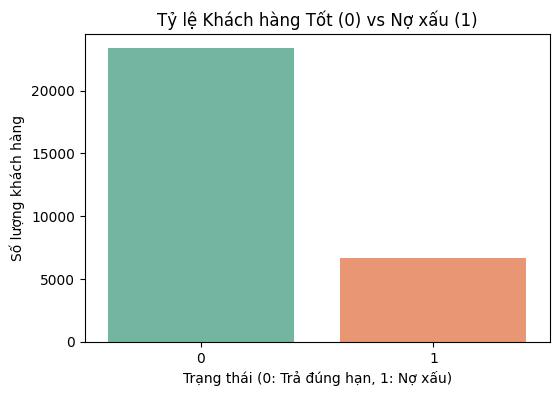

--- ĐÃ HOÀN THÀNH TIỀN XỬ LÝ DỮ LIỆU ---
Số mẫu tập Học (Train): 24000 dòng
Số mẫu tập Kiểm tra (Test): 6000 dòng


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Đổi tên cột mục tiêu cuối cùng thành 'TARGET' cho dễ viết code
df.rename(columns={df.columns[-1]: 'TARGET'}, inplace=True)

# 2. Vẽ biểu đồ xem tỷ lệ nợ xấu
plt.figure(figsize=(6, 4))
sns.countplot(x='TARGET', data=df, palette='Set2')
plt.title('Tỷ lệ Khách hàng Tốt (0) vs Nợ xấu (1)')
plt.xlabel('Trạng thái (0: Trả đúng hạn, 1: Nợ xấu)')
plt.ylabel('Số lượng khách hàng')
plt.show()

# 3. Tách biến tính năng (X) và biến mục tiêu (y)
X = df.drop(columns=['TARGET'])
y = df['TARGET']

# 4. Chia dữ liệu thành 2 tập: Train (80%) và Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Chuẩn hóa dữ liệu để các cột tiền lớn và tuổi tác có cùng thang đo
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("--- ĐÃ HOÀN THÀNH TIỀN XỬ LÝ DỮ LIỆU ---")
print(f"Số mẫu tập Học (Train): {X_train_scaled.shape[0]} dòng")
print(f"Số mẫu tập Kiểm tra (Test): {X_test_scaled.shape[0]} dòng")

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Khởi tạo và huấn luyện mô hình Hồi quy Logistic
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# 2. Dự đoán trên tập dữ liệu kiểm tra (Test)
y_pred = model.predict(X_test_scaled)

# 3. In kết quả để đưa vào bảng báo cáo
print("=== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ===")
print(f"Độ chính xác tổng thể (Accuracy): {accuracy_score(y_test, y_pred):.4f}\n")

print("--- BÁO CÁO CHI TIẾT (Classification Report) ---")
print(classification_report(y_test, y_pred))

print("--- MA TRẬN NHẦM LẪN (Confusion Matrix) ---")
print(confusion_matrix(y_test, y_pred))

=== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ===
Độ chính xác tổng thể (Accuracy): 0.8080

--- BÁO CÁO CHI TIẾT (Classification Report) ---
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.69      0.24      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.75      0.61      0.62      6000
weighted avg       0.79      0.81      0.77      6000

--- MA TRẬN NHẦM LẪN (Confusion Matrix) ---
[[4528  145]
 [1007  320]]
